In [70]:
%matplotlib qt
import numpy as np
import matplotlib.pyplot as plt

class MapMaker:
    def __init__(self, N=15):
        self.N = N
        # Initialize with random spins (-1, 1)
        self.config = 2 * np.random.randint(2, size=(N, N)) - 1
        
        self.fig, self.ax = plt.subplots(figsize=(8, 8))
        self.im = self.ax.imshow(self.config, cmap='RdBu', vmin=-1, vmax=1, origin='lower')
        
        self.ax.set_title("Click to set spin to 0 (White)")
        # Connect the click event
        self.cid = self.fig.canvas.mpl_connect('button_press_event', self.onclick)
        
        plt.show()

    def onclick(self, event):
        # Check if the click was inside the axes
        if event.inaxes == self.ax:
            # Convert coordinate click to integer index
            ix, iy = int(round(event.xdata)), int(round(event.ydata))
            
            # Bound check to ensure click is inside the grid
            if 0 <= ix < self.N and 0 <= iy < self.N:
                # Set the spin to 0
                self.config[iy, ix] = 0
                
                # Update the display
                self.im.set_array(self.config)
                self.fig.canvas.draw()

# Run the app
maker = MapMaker(N=20)

In [ ]:
%matplotlib inline
# Simulating the Ising model
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt

class Ising():
    ''' Simulating the Ising model '''    
    ## monte carlo moves
    def mcmove(self, config, N, beta):
        ''' This is to execute the monte carlo moves using 
        Metropolis algorithm such that detailed
        balance condition is satisified'''
        for i in range(N):
            for j in range(N):            
                    a = np.random.randint(0, N)
                    b = np.random.randint(0, N)
                    s =  config[a, b]
                    if s != 0:
                        nb = config[(a+1)%N,b] + config[a,(b+1)%N] + config[(a-1)%N,b] + config[a,(b-1)%N]
                        cost = 2*s*nb
                        if cost < 0:	
                            s *= -1
                        elif rand() < np.exp(-cost*beta):
                            s *= -1
                        config[a, b] = s
                    else:
                        continue
        return config
    
    def simulate(self):   
        ''' This module simulates the Ising model'''
        impurity_ratio = 0.3
        N, temp     = maker.N, .4        # Initialse the lattice
        config = np.random.choice([-1, 0, 1], size=(N,N), p=[(1-impurity_ratio)/2, impurity_ratio, (1-impurity_ratio)/2])
        config = maker.config
        f = plt.figure(figsize=(15, 15), dpi=80);    
        self.configPlot(f, config, 0, N, 1);
        
        msrmnt = 2501
        for i in range(msrmnt):
            self.mcmove(config, N, 1.0/temp)
            if i == 1:       self.configPlot(f, config, i, N, 2);
            if i == 4:       self.configPlot(f, config, i, N, 3);
            if i == 32:      self.configPlot(f, config, i, N, 4);
            if i == 100:     self.configPlot(f, config, i, N, 5);
            if i == 1000:    self.configPlot(f, config, i, N, 6);
            if i == msrmnt-1:    self.configPlot(f, config, i, N, 7);
                 
                    
    def configPlot(self, f, config, i, N, n_):
        ''' This modules plts the configuration once passed to it along with time etc '''
        X, Y = np.meshgrid(range(N), range(N))
        sp =  f.add_subplot(3, 3, n_ )  
        plt.setp(sp.get_yticklabels(), visible=False)
        plt.setp(sp.get_xticklabels(), visible=False)      
        plt.pcolormesh(X, Y, config, cmap=plt.cm.RdBu, vmin=-1, vmax=1);
        plt.title('Time=%d'%i); plt.axis('tight')    
    plt.show()

In [78]:
rm = Ising()

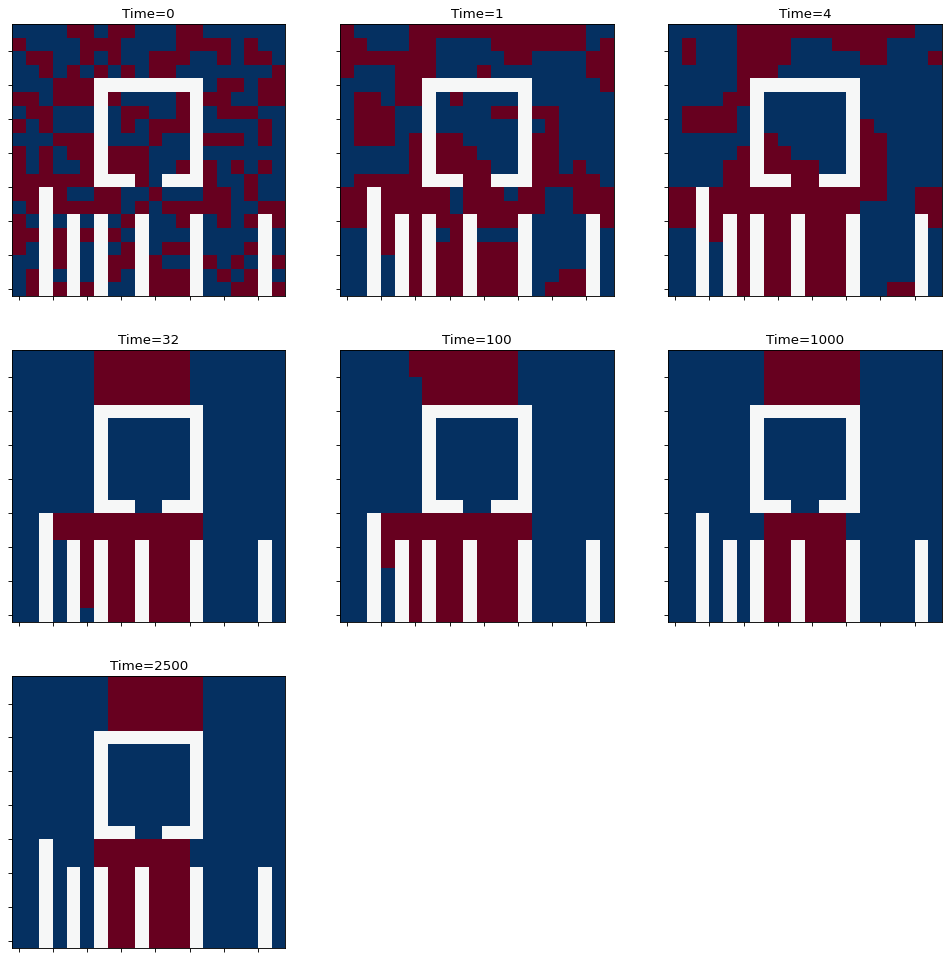

In [79]:
rm.simulate()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Ensure you have PyQt5 installed: pip install PyQt5
try:
    matplotlib.use('Qt5Agg')
except:
    pass 

class InteractiveIsing:
    def __init__(self, N=30, temp=0.4):
        self.N = N
        self.temp = temp
        self.beta = 1.0 / temp
        self.running = False
        
        self.config = np.random.choice([-2,-1, 1, 2], size=(N,N))
        
        # 2. Setup Plotting
        self.fig, self.ax = plt.subplots(figsize=(8, 8))
        self.im = self.ax.imshow(self.config, cmap='RdBu', vmin=-2, vmax=2, origin='lower')
        
        self.ax.set_title("CLICK to draw '0' sites | Press SPACE to Start/Pause")
        
        # 3. Connect Events
        self.fig.canvas.mpl_connect('button_press_event', self.onclick)
        self.fig.canvas.mpl_connect('key_press_event', self.on_key)
        
        # 4. Animation Timer
        self.timer = self.fig.canvas.new_timer(interval=10)
        self.timer.add_callback(self.simulate_step)
        
        plt.show()

    def onclick(self, event):
        """Sets a site to 0 when clicked"""
        if event.inaxes == self.ax:
            ix, iy = int(round(event.xdata)), int(round(event.ydata))
            if 0 <= ix < self.N and 0 <= iy < self.N:
                self.config[iy, ix] = 0
                self.im.set_array(self.config)
                self.fig.canvas.draw()

    def on_key(self, event):
        """Starts/Pauses simulation on Spacebar"""
        if event.key == ' ':
            if self.running:
                self.timer.stop()
                self.ax.set_title("PAUSED | Click to edit")
            else:
                self.timer.start()
                self.ax.set_title("RUNNING... | Press Space to Pause")
            self.running = not self.running
            self.fig.canvas.draw()
        if event.key == 'r':
            self.config = np.random.choice([-2,-1, 1, 2], size=(N,N))

    def simulate_step(self):
        """One full Monte Carlo sweep"""
        N = self.N
        # Metropolis Algorithm
        for _ in range(N**2): # Perform N^2 attempts per frame
            a = np.random.randint(0, N)
            b = np.random.randint(0, N)
            s = self.config[a, b]
            
            if s != 0: # Only flip non-zero spins
                # Calculate neighbor sum (periodic boundaries)
                nb = (self.config[(a+1)%N, b] + self.config[(a-1)%N, b] + 
                      self.config[a, (b+1)%N] + self.config[a, (b-1)%N])
                
                cost = 2 * s * nb
                if cost < 0 or np.random.rand() < np.exp(-cost * self.beta):
                    self.config[a, b] = -s
        
        self.im.set_array(self.config)
        self.fig.canvas.draw()

# Run the simulation
if __name__ == "__main__":
    sim = InteractiveIsing(N=40, temp=0.5)

Traceback (most recent call last):
  File "/Users/numanlaanait/Documents/dev/.venv/lib/python3.9/site-packages/matplotlib/cbook.py", line 298, in process
    func(*args, **kwargs)
  File "/var/folders/cs/lpq6y7s56cn9tb7dft92q7140000gn/T/ipykernel_8088/2170535539.py", line 57, in on_key
    self.config = np.random.choice([-2,-1, 1, 2], size=(N,N))
NameError: name 'N' is not defined
Traceback (most recent call last):
  File "/Users/numanlaanait/Documents/dev/.venv/lib/python3.9/site-packages/matplotlib/cbook.py", line 298, in process
    func(*args, **kwargs)
  File "/var/folders/cs/lpq6y7s56cn9tb7dft92q7140000gn/T/ipykernel_8088/2170535539.py", line 57, in on_key
    self.config = np.random.choice([-2,-1, 1, 2], size=(N,N))
NameError: name 'N' is not defined
Traceback (most recent call last):
  File "/Users/numanlaanait/Documents/dev/.venv/lib/python3.9/site-packages/matplotlib/cbook.py", line 298, in process
    func(*args, **kwargs)
  File "/var/folders/cs/lpq6y7s56cn9tb7dft92q7140000